# Avazu CTR Prediction
Notebook 01: Data Understanding
# Project Objective
The purpose of this project is to build a machine learning model that predicts the probability that a user will click a digital advertisement.
The Kaggle Avazu CTR Prediction dataset is used for this project.
Each row represents one ad impression.

# The target column is `click`:
- `click = 1`: the advertisement was clicked
- `click = 0`: the advertisement was not clicked

### Objective of this notebook

In this notebook, I will:
1.Load and inspect the raw Avazu dataset.
2.Understand the number of rows and columns.
3.Examine column names and data types.
4.Analyze the click target.
5.Check missing values.
6.Check duplicate records.
7.Identify high-cardinality categorical features.
8.Examine the time range.

## 1. Load and inspect the raw Avazu dataset

In [36]:
import os
import sys
import platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
train_path = Path("../data/raw/train.gz")

In [12]:
df = pd.read_csv(train_path)

In [13]:
df.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1.000009e+18,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,2,15706,320,50,1722,0,35,-1,79
1,1.000017e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
2,1.000037e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
3,1.000064e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15706,320,50,1722,0,35,100084,79
4,1.000068e+19,0,14102100,1005,1,fe8cc448,9166c161,0569f928,ecad2386,7801e8d9,...,1,0,18993,320,50,2161,0,35,-1,157


In [17]:
df.tail()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
40428962,9.998753e+18,1,14103023,1005,1,e151e245,7e091613,f028772b,ecad2386,7801e8d9,...,1,0,17262,320,50,1872,3,39,100173,23
40428963,9.999038e+18,0,14103023,1005,0,85f751fd,c4e18dd6,50e219e0,9c13b419,2347f47a,...,1,2,23160,320,50,2667,0,47,-1,221
40428964,9.999585e+18,0,14103023,1005,1,f61eaaae,6b59f079,f028772b,ecad2386,7801e8d9,...,1,0,20969,320,50,2372,0,813,-1,46
40428965,9.999636e+18,1,14103023,1005,0,85f751fd,c4e18dd6,50e219e0,3c4b944d,2347f47a,...,1,0,16859,320,50,1887,3,39,100194,23
40428966,9.999747e+18,0,14103023,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,22257,320,50,2545,0,431,100084,221


## 2. Understand the number of rows and columns

In [14]:
df.shape

(40428967, 24)

## 3. Examine column names and data types

In [15]:
df.columns

Index(['id', 'click', 'hour', 'C1', 'banner_pos', 'site_id', 'site_domain',
       'site_category', 'app_id', 'app_domain', 'app_category', 'device_id',
       'device_ip', 'device_model', 'device_type', 'device_conn_type', 'C14',
       'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21'],
      dtype='str')

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40428967 entries, 0 to 40428966
Data columns (total 24 columns):
 #   Column            Dtype  
---  ------            -----  
 0   id                float64
 1   click             int64  
 2   hour              int64  
 3   C1                int64  
 4   banner_pos        int64  
 5   site_id           str    
 6   site_domain       str    
 7   site_category     str    
 8   app_id            str    
 9   app_domain        str    
 10  app_category      str    
 11  device_id         str    
 12  device_ip         str    
 13  device_model      str    
 14  device_type       int64  
 15  device_conn_type  int64  
 16  C14               int64  
 17  C15               int64  
 18  C16               int64  
 19  C17               int64  
 20  C18               int64  
 21  C19               int64  
 22  C20               int64  
 23  C21               int64  
dtypes: float64(1), int64(14), str(9)
memory usage: 7.2 GB


## 4. Analyze the click target

In [18]:
df["click"].unique()

array([0, 1])

In [19]:
click_counts = df["click"].value_counts().sort_index()
click_counts

click
0    33563901
1     6865066
Name: count, dtype: int64

In [23]:
click_percentage = (df["click"].value_counts(normalize=True).sort_index().mul(100))
print(click_percentage)

click
0    83.019438
1    16.980562
Name: proportion, dtype: float64


## 5. Check missing values

In [25]:
missing_counts = df.isna().sum()
missing_counts

id                  0
click               0
hour                0
C1                  0
banner_pos          0
site_id             0
site_domain         0
site_category       0
app_id              0
app_domain          0
app_category        0
device_id           0
device_ip           0
device_model        0
device_type         0
device_conn_type    0
C14                 0
C15                 0
C16                 0
C17                 0
C18                 0
C19                 0
C20                 0
C21                 0
dtype: int64

## 6. Check duplicate records

In [27]:
duplicate_rows = df.duplicated().sum()
duplicate_rows

np.int64(0)

# 7. Identify high-cardinality categorical features
Cardinality means the number of unique values in a column.
High-cardinality categorical features contain many categories. Examples may include device IDs, IP identifiers, site IDs, app IDs, and device models.
These columns require special encoding because regular one-hot encoding could create an extremely large feature matrix.


In [30]:
unique_counts = df.nunique(dropna=False).sort_values(ascending=False)
unique_counts

id                  40428967
device_ip            6729486
device_id            2686408
app_id                  8552
device_model            8251
site_domain             7745
site_id                 4737
C14                     2626
app_domain               559
C17                      435
hour                     240
C20                      172
C19                       68
C21                       60
app_category              36
site_category             26
C16                        9
C15                        8
C1                         7
banner_pos                 7
device_type                5
device_conn_type           4
C18                        4
click                      2
dtype: int64

# Very high cardinality
device_ip       6,729,486
device_id       2,686,408
app_id              8,552
device_model         8,251
site_domain          7,745
site_id              4,737
C14                  2,626
# Medium cardinality
app_domain       559
C17              435
C20              172
## Hour should not be treated as a normal category directly. It should be converted into time features such as:
day
hour_of_day
day_of_week
weekend
## Low cardinality
C19                  68
C21                  60
app_category         36
site_category        26
C16                   9
C15                   8
C1                    7
banner_pos            7
device_type           5
device_conn_type      4
C18                   4
These can usually be one-hot encoded or handled directly as categorical features.

## 8. Examine the time range

In [32]:
df[["hour"]].head()

,hour
0,14102100
1,14102100
2,14102100
3,14102100
4,14102100


In [33]:
print("Data type of hour:", df["hour"].dtype)

Data type of hour: int64


## Hours require engineering and change in the data type to string. because to support date format

## Click and non-click counts

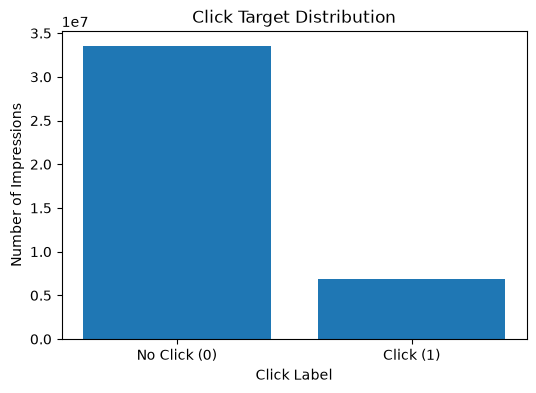

In [39]:
click_counts = df["click"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(["No Click (0)", "Click (1)"], click_counts.values)
plt.title("Click Target Distribution")
plt.xlabel("Click Label")
plt.ylabel("Number of Impressions")
plt.show()